In [1]:
import os, sys, torch, rasterio, importlib
from pathlib import Path
import numpy as np

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(os.path.join(project_root, "src"))

from config import DATA_DIR, DATA_MODELS
import pretrain_unet
from argparse import Namespace

API KEY Successfully loaded


In [ ]:
print("Python:", sys.version)
print("CWD:", os.getcwd())
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)
print("Rasterio:", rasterio.__version__)
print (DATA_DIR/"pretraining")
print (DATA_MODELS)


In [ ]:
args_train = Namespace(
    # dataset / paths
    dataset="pretraining",
    images=None, masks=None, splits=None, stats=None,

    # reproducibilidad
    seed=42,
    cpu=False,

    # data / model
    bands=[1,2,3,4,5,6,7,8],
    base_c=64,

    # loader
    batch_size=16,
    num_workers=8,

    # training
    epochs=60,
    min_epochs=20,
    patience=10,
    lr=1e-4,
    wd=1e-4,

    # output
    out_name="unet_8b_v1"
)

In [ ]:
act_training=pretrain_unet.run(args_train)

In [ ]:
import visualize_unet


res = visualize_unet.run_visualization(
    dataset="pretraining",
    split="val",
    out_name="unet_8b_v1",
    ckpt="best.pth",
    n_samples=15,
    threshold=0.5
)
res["save_dir"], res["montage"]

In [ ]:
args_train = Namespace(
    mode="train",
    dataset="pretraining",      # carpeta bajo DATA_DIR
    images=None, masks=None, splits=None, stats=None,  # sin overrides
    seed=42,
    cpu=False,
    bands=[1,2,3,4,5,6,7,8],
    batch_size=16,               # pequeño para prueba
    num_workers=4,
    base_c=32,
    epochs=80,
    min_epochs=20,
    patience=10,
    lr=1e-4,
    wd=1e-4,
    out_name="unet_8b_v1",
    split="val",
    ckpt="best.pth",
    threshold=0.45
)

In [ ]:
args_eval = Namespace(
    # dataset / paths
    dataset="pretraining",
    images=None, masks=None, splits=None, stats=None,

    # reproducibilidad
    seed=42,
    cpu=False,

    # data / model
    bands=[1,2,3,4,5,6,7,8],
    base_c=64,

    # loader
    batch_size=16,
    num_workers=6,

    # evaluation
    out_name="unet_8b_v1",
    split="test",
    ckpt="best.pth",
    threshold=0.55
)

In [ ]:
eval=pretrain_unet.run_eval(args_eval)

In [ ]:
from importlib import reload
import visualize_unet
reload(visualize_unet)

res = visualize_unet.run_visualization(
    dataset="pretraining",
    split="val",
    out_name="smoke_test_v1",
    ckpt="best.pth",
    n_samples=6,
    threshold=0.5
)
res["save_dir"], res["montage"]

# Entrenamiento2

In [ ]:
args_train2 = Namespace(
    # dataset / paths
    dataset="pretraining",
    images=None, masks=None, splits=None, stats=None,

    # reproducibilidad
    seed=42,
    cpu=False,

    # data / model
    bands=[1,2,3,4,5,6,7,8],
    base_c=32,

    # loader
    batch_size=16,
    num_workers=4,

    # training
    epochs=80,
    min_epochs=20,
    patience=8,
    lr=1e-4,
    wd=1e-4,

    # output
    out_name="unet_8b_v2"
)

In [ ]:
act_training2=pretrain_unet.run(args_train2)

In [ ]:
args_eval2 = Namespace(
    # dataset / paths
    dataset="pretraining",
    images=None, masks=None, splits=None, stats=None,

    # reproducibilidad
    seed=42,
    cpu=False,

    # data / model
    bands=[1,2,3,4,5,6,7,8],
    base_c=32,

    # loader
    batch_size=16,
    num_workers=4,

    # evaluation
    out_name="unet_8b_v2",
    split="test",
    ckpt="best.pth",
    threshold=0.50
)

In [ ]:
eval2=pretrain_unet.run_eval(args_eval2)

In [ ]:
res = visualize_unet.run_visualization(
    dataset="pretraining",
    split="val",
    out_name="unet_8b_v2",
    ckpt="best.pth",
    n_samples=12,
    threshold=0.5,
    base_c=32,
    bands=[1,2,3,4,5,6,7,8]
)
res["save_dir"], res["montage"]

# Entrenamiento3

In [ ]:
args_train3 = Namespace(
    # dataset / paths
    dataset="pretraining",
    images=None, masks=None, splits=None, stats=None,

    # reproducibilidad
    seed=42,
    cpu=False,

    # data / model
    bands=[1,2,3,4,5,6,7,8],
    base_c=64,

    # loader
    batch_size=16,
    num_workers=8,

    # training
    epochs=100,
    min_epochs=10,
    patience=15,
    lr=1e-4,
    wd=1e-4,

    # output
    out_name="unet_8b_v3"
)

In [ ]:
act_training3=pretrain_unet.run(args_train3)

# Entrenamiento4

In [ ]:
args_train4 = Namespace(
    # dataset / paths
    dataset="pretraining",
    images=None, masks=None, splits=None, stats=None,

    # reproducibilidad
    seed=42,
    cpu=False,

    # data / model
    bands=[1,2,3,4,5,6,7,8],
    base_c=64,

    # loader
    batch_size=16,
    num_workers=8,

    # training
    epochs=80,
    min_epochs=10,
    patience=8,
    lr=5e-5,
    wd=1e-4,

    # output
    out_name="unet_8b_v4"
)

In [ ]:
act_training4=pretrain_unet.run(args_train4)

# Entrenamiento5 EL MEJOR AL MOMENTO

In [2]:
args_train5 = Namespace(
    # dataset / paths
    dataset="pretraining",
    images=None, masks=None, splits=None, stats=None,

    # reproducibilidad
    seed=42,
    cpu=False,

    # data / model
    bands=[1,2,3,4,5,6,7,8],
    base_c=64,

    # loader
    batch_size=16,
    num_workers=8,

    # training
    epochs=80,
    min_epochs=20,
    patience=10,
    lr=1e-5,
    wd=1e-4,

    # output
    out_name="unet_8b_v5"
)

Device: cuda
In channels: 8

=== Training outputs ===
Run directory : /home/student/Documents/jaar/GIT/data/models/building_pretrain/unet_8b_v5
Best model    : /home/student/Documents/jaar/GIT/data/models/building_pretrain/unet_8b_v5/best.pth
Last model    : /home/student/Documents/jaar/GIT/data/models/building_pretrain/unet_8b_v5/last.pth
History file : /home/student/Documents/jaar/GIT/data/models/building_pretrain/unet_8b_v5/history.npy
Run config   : /home/student/Documents/jaar/GIT/data/models/building_pretrain/unet_8b_v5/run_config.json

Epoch 001 | 46.4s | train loss 0.6571 iou 0.198 f1 0.322 | val loss 0.6210 iou 0.237 f1 0.380 | GPU mem 0.52G (max 12.73G) | ~batch 0.516s
  ↳ new best val IoU: 0.237 (checkpoint saved)
Epoch 002 | 44.3s | train loss 0.5771 iou 0.267 f1 0.418 | val loss 0.5539 iou 0.278 f1 0.432 | GPU mem 0.52G (max 12.73G) | ~batch 0.509s
  ↳ new best val IoU: 0.278 (checkpoint saved)
Epoch 003 | 45.2s | train loss 0.5331 iou 0.290 f1 0.447 | val loss 0.5144 iou 

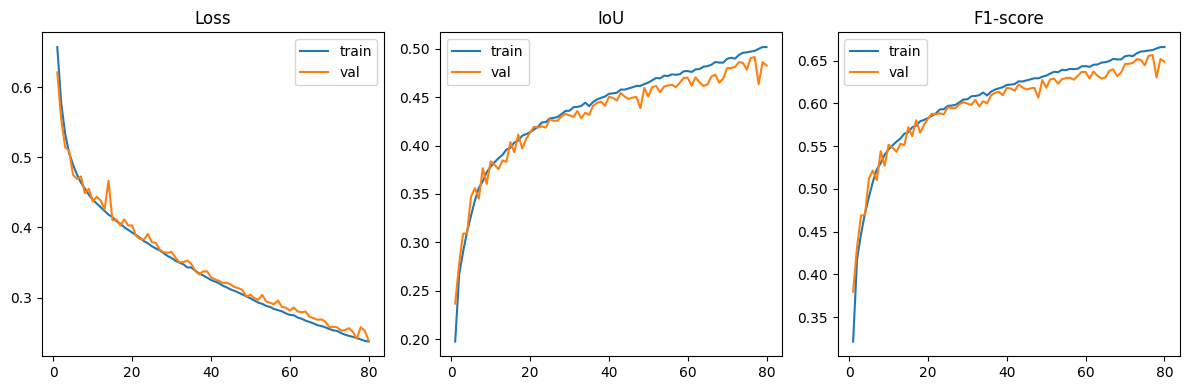

In [3]:
act_training5=pretrain_unet.run(args_train5)

In [5]:
args_train6 = Namespace(
    # dataset / paths
    dataset="pretraining",
    images=None, masks=None, splits=None, stats=None,

    # reproducibilidad
    seed=42,
    cpu=False,

    # data / model
    bands=[1,2,3,4,5,6,7,8],
    base_c=64,

    # loader
    batch_size=16,
    num_workers=8,

    # training
    epochs=100,
    min_epochs=10,
    patience=8,
    lr=5e-5,
    wd=1e-4,

    # output
    out_name="unet_8b_v6"
)

In [4]:
act_training6=pretrain_unet.run(args_train6)

NameError: name 'args_train6' is not defined

##### Visualizations with the selected 5th training.

In [ ]:
from importlib import reload
import visualize_unet
reload(visualize_unet)

res = visualize_unet.run_visualization(
    dataset="pretraining",
    split="val",
    out_name="unet_8b_v5",
    ckpt="best.pth",
    n_samples=6,
    threshold=0.5
)
res["save_dir"], res["montage"]